# Reddit dataset - basic metrics

Dataset = the two parquet files in `data/` (Reddit posts mentioning Trump, 2017-01..06 + 2018-01..06).
Nothing loads full data — sizes from stat(), rows from the parquet footer, category counts streamed per row-group (one column).

In [1]:
from collections import Counter
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

DATA = next(p for p in (Path.cwd() / "data", Path.cwd().parent / "data") if p.is_dir())
FILES = {"submissions": DATA / "submissions_trump.parquet", "comments": DATA / "comments_trump.parquet"}
files = {k: pq.ParquetFile(p) for k, p in FILES.items()}

## size, rows, breakdown by type

In [2]:
overview = pd.DataFrame(
    {
        "size_MB": [FILES[k].stat().st_size / 1024**2 for k in files],
        "rows": [f.metadata.num_rows for f in files.values()],
    },
    index=list(files),
)
overview["rows_%"] = 100 * overview["rows"] / overview["rows"].sum()
overview.loc["TOTAL"] = overview.sum()
overview.round(1)

,size_MB,rows,rows_%
submissions,246.3,513848.0,10.0
comments,1319.2,4601620.0,90.0
TOTAL,1565.5,5115468.0,100.0


A plain read_parquet would need ~7.3 GB RAM for comments, ~8.5 GB for both files (measured below from a sample, extrapolated by row count).

In [3]:
def est_pandas_gb(name, batch=20_000):
    f = files[name]
    # one batch from the start of every row group so different periods are sampled
    sample = pd.concat(
        next(f.iter_batches(batch_size=batch, row_groups=[i])).to_pandas()
        for i in range(f.metadata.num_row_groups)
    )
    per_row = sample.memory_usage(deep=True).sum() / len(sample)
    return {"sample_rows": len(sample), "bytes_per_row": per_row,
            "est_pandas_GB": per_row * f.metadata.num_rows / 1024**3}


est = pd.DataFrame({k: est_pandas_gb(k) for k in files}).T
est.loc["TOTAL", "est_pandas_GB"] = est["est_pandas_GB"].sum()
est.round(2)

,sample_rows,bytes_per_row,est_pandas_GB
submissions,20000.0,2434.96,1.17
comments,100000.0,1701.35,7.29
TOTAL,NaN,NaN,8.46


## counts per category

Two categorical columns present in both files: `subreddit` and `source_month`.
Counted row-group by row-group so the 1.4 GB comments file never lands in RAM at once.

In [4]:
def count_by(name, column):
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        counts.update(f.read_row_group(i, columns=[column])[column].to_pylist())
    return pd.Series(counts, name=name).sort_values(ascending=False)


by_month = pd.concat([count_by(k, "source_month") for k in files], axis=1).sort_index()
by_month

,submissions,comments
2017-01,39253,378728
2017-02,38588,321216
2017-03,33887,290558
2017-04,26421,203596
2017-05,35318,297488
2017-06,26793,264068
2018-01,28963,256804
2018-02,23134,196872
2018-03,26994,225168
2018-04,24080,216950


In [5]:
by_sub = pd.concat([count_by(k, "subreddit") for k in files], axis=1).fillna(0).astype(int)
print(f"distinct subreddits: {len(by_sub):,}")
by_sub.sort_values("comments", ascending=False).head(15)

distinct subreddits: 6


,submissions,comments
politics,410652,4161278
AskTrumpSupporters,29196,173211
Conservative,42467,102922
PoliticalDiscussion,7666,93890
democrats,17357,54506
Republican,6510,15813


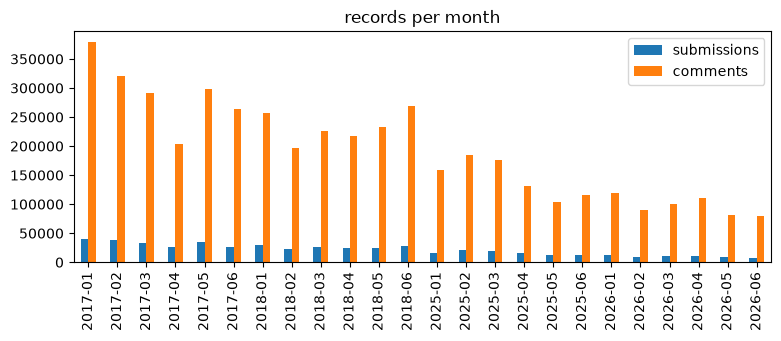

In [6]:
by_month.plot.bar(figsize=(9, 3), title="records per month");

## duplicates

Reddit `id` is unique per comment / per submission, so a repeated id = same record collected twice. Only the `id` column is read (~50 MB).

In [7]:
import pyarrow.compute as pc


def dup_check(name):
    ids = files[name].read(columns=["id"])["id"]
    valid = len(ids) - ids.null_count
    return {"rows": len(ids), "null_ids": ids.null_count, "duplicate_rows": valid - pc.count_distinct(ids).as_py()}


pd.DataFrame({k: dup_check(k) for k in files}).T

,rows,null_ids,duplicate_rows
submissions,513848,0,0
comments,4601620,0,0


## head

First 3 rows, transposed (132 / 87 columns). Note: first rows are all 2017-01.

In [8]:
import pyarrow as pa

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 60):
    for k, f in files.items():
        print(k)
        display(next(f.iter_batches(batch_size=3)).to_pandas().T)

submissions


,0,1,2
score,1,266,1
suggested_sort,NaN,NaN,NaN
author_flair_css_class,NaN,NaN,NaN
media,NaN,NaN,NaN
permalink,/r/politics/comments/5lch1i/trump_ditches_press_pool_to_...,/r/politics/comments/5lci8r/putin_won_2016_but_russia_ha...,/r/politics/comments/5lciy3/this_photo_of_a_trump_billbo...
selftext,NaN,NaN,[deleted]
archived,False,False,False
url,http://www.cnn.com/2016/12/31/politics/donald-trump-pres...,https://www.washingtonpost.com/world/europe/putin-won-20...,http://m.huffpost.com/us/entry/us_586813c3e4b0d9a5945bb091
subreddit,politics,politics,politics
subreddit_id,t5_2cneq,t5_2cneq,t5_2cneq


comments


,0,1,2
subreddit_id,t5_2cneq,t5_2cneq,t5_2cneq
retrieved_on,1485679713,1485679725,1485679726
author_flair_css_class,us-flag,minnesota-flag,us-flag
author_flair_text,America,Minnesota,America
controversiality,1,0,1
link_id,t3_5lbx9q,t3_5lbdw1,t3_5lbx9q
score,4,7,0
author,GaryRuppert,Kichigai,GaryRuppert
subreddit,politics,politics,politics
body,Kind of a shame for Bill Clinton that he's determined to...,"Please, McCain has done more to try and unite the countr...",remember when Dems said Trump had no GOTV operation?


## missing values

Null counts straight from the parquet footer (no data read). NaN in the table = column not in that file.

In [9]:
def null_counts(name):
    f = files[name]
    md = f.metadata
    out = {}
    for j in range(md.num_columns):
        stats = [md.row_group(i).column(j).statistics for i in range(md.num_row_groups)]
        c = md.schema.column(j).name
        if all(s is not None and s.has_null_count for s in stats):
            out[c] = sum(s.null_count for s in stats)
        else:  # no footer stats (all-null columns) -> read it, cheap
            out[c] = f.read(columns=[c])[c].null_count
    s = pd.Series(out)
    return pd.DataFrame({"nulls": s, "null_%": (100 * s / md.num_rows).round(1)})


nulls = pd.concat({k: null_counts(k) for k in files}, axis=1)
all_null = {k: nulls.index[nulls[(k, "nulls")] == files[k].metadata.num_rows].tolist() for k in files}
for k, cols in all_null.items():
    print(f"{k}: {len(cols)} columns 100% null (drop):", cols)
with pd.option_context("display.max_rows", None):
    display(nulls[(nulls.xs("null_%", axis=1, level=1) > 0).any(axis=1)].sort_values(("comments", "null_%")))

submissions: 20 columns 100% null (drop): ['view_count', 'approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'category', 'content_categories', 'likes', 'num_reports', 'post_categories', 'report_reasons', 'discussion_type', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'removed_by', 'top_awarded_type', 'location_lat', 'location_long', 'location_name']
comments: 15 columns 100% null (drop): ['approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'likes', 'num_reports', 'report_reasons', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'top_awarded_type', 'associated_award', 'collapsed_because_crowd_control', 'comment_type', 'unrepliable_reason']


submissions          comments       
                                      nulls null_%      nulls null_%
can_gild                           226103.0   44.0   990502.0   21.5
permalink                               0.0    0.0  1755654.0   38.2
subreddit_type                     200260.0   39.0  1755654.0   38.2
is_submitter                            NaN    NaN  1755654.0   38.2
send_replies                       229223.0   44.6  2209330.0   48.0
no_follow                          229223.0   44.6  2209330.0   48.0
archived                                0.0    0.0  2434498.0   52.9
can_mod_post                       300654.0   58.5  2433783.0   52.9
score_hidden                            NaN    NaN  2434498.0   52.9
author_flair_richtext              298073.0   58.0  2888458.0   62.8
author_flair_type                  298073.0   58.0  2888458.0   62.8
mod_reports                        306745.0   59.7  3080217.0   66.9
user_reports                       306745.0   59.7  3080217.0   66.9
saved                              306745.0   59.7  3080217.0   66.9
downs                              306745.0   59.7  3152758.0   68.5
name                               306745.0   59.7  3152758.0   68.5
all_awardings                      354844.0   69.1  3152758.0   68.5
author_is_blocked                  354844.0   69.1  3152758.0   68.5
treatment_tags                     354844.0   69.1  3152758.0   68.5
total_awards_received              354844.0   69.1  3152758.0   68.5
replies                                 NaN    NaN  3152758.0   68.5
collapsed                               NaN    NaN  3152758.0   68.5
gildings                           354844.0   69.1  3152758.0   68.5
awarders                           354844.0   69.1  3152758.0   68.5
subreddit_name_prefixed            327447.0   63.7  3152758.0   68.5
ups                                306745.0   59.7  3152758.0   68.5
author_patreon_flair               357507.0   69.6  3152764.0   68.5
author_premium                     357507.0   69.6  3152764.0   68.5
locked                                  0.0    0.0  3152758.0   68.5
created                            306745.0   59.7  3152758.0   68.5
_meta                              356402.0   69.4  3155599.0   68.6
author_fullname                    335526.0   65.3  3159565.0   68.7
author_flair_text                  400918.0   78.0  3753784.0   81.6
author_flair_css_class             422885.0   82.3  3815637.0   82.9
profile_over_18                         NaN    NaN  4138738.0   89.9
profile_img                             NaN    NaN  4138738.0   89.9
author_flair_text_color            431820.0   84.0  4280028.0   93.0
author_flair_template_id           462518.0   90.0  4283899.0   93.1
rte_mode                           465749.0   90.6  4332984.0   94.2
author_flair_background_color      481245.0   93.7  4477324.0   97.3
body_html                               NaN    NaN  4529079.0   98.4
distinguished                      513445.0   99.9  4559433.0   99.1
author_cakeday                     512513.0   99.7  4587940.0   99.7
collapsed_reason_code                   NaN    NaN  4594517.0   99.8
num_comments                            0.0    0.0  4601174.0  100.0
banned_by                          513848.0  100.0  4601620.0  100.0
over_18                                 0.0    0.0  4601174.0  100.0
quarantine                         127187.0   24.8  4601174.0  100.0
report_reasons                     513848.0  100.0  4601620.0  100.0
removal_reason                     513846.0  100.0  4601595.0  100.0
num_reports                        513848.0  100.0  4601620.0  100.0
likes                              513848.0  100.0  4601620.0  100.0
approved_by                        513848.0  100.0  4601620.0  100.0
mod_reason_by                      513848.0  100.0  4601620.0  100.0
media_metadata                     513602.0  100.0  4600860.0  100.0
mod_note                           513848.0  100.0  4601620.0  100.0
top_awarded_type              

In [10]:
# nulls come in whole-month blocks (field missing from that period's dump) -> % null per month
def null_pct_by_month(name, cols):
    f = files[name]
    month = f.read(columns=["source_month"])["source_month"].to_pandas()
    return pd.DataFrame({c: f.read(columns=[c])[c].is_null().to_pandas().groupby(month).mean() * 100 for c in cols}).T.round().astype(int)


with pd.option_context("display.max_rows", None, "display.max_columns", None):
    for k in files:
        partial = nulls.index[(nulls[(k, "nulls")] > 0) & (nulls[(k, "nulls")] < files[k].metadata.num_rows)]
        print(k)
        display(null_pct_by_month(k, partial))

submissions


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
suggested_sort,93,92,94,92,93,94,96,96,96,96,95,94,65,65,71,74,75,76,91,92,91,91,91,92
author_flair_css_class,86,84,88,81,81,83,83,81,82,100,100,91,75,76,77,76,73,71,71,72,70,70,69,69
media,96,97,97,98,98,98,98,99,99,99,99,99,97,96,96,97,97,97,98,98,98,98,98,98
selftext,71,71,74,72,73,74,75,76,77,75,75,76,0,0,0,0,0,0,0,0,0,0,0,0
brand_safe,0,0,0,0,0,0,0,0,0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
author_flair_text,84,83,86,80,80,82,82,80,81,100,100,77,67,70,69,67,63,61,62,61,61,60,59,57
link_flair_text,59,65,64,63,65,58,72,73,70,74,73,75,37,38,38,40,39,39,8,7,7,6,6,6
thumbnail,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
distinguished,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
link_flair_css_class,90,91,92,92,90,90,83,83,79,83,83,85,64,64,68,72,73,71,74,76,78,75,77,78


comments


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
author_flair_css_class,87,84,86,84,82,82,80,82,80,80,79,80,86,85,85,84,84,84,84,84,83,83,81,83
permalink,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
archived,100,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
over_18,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,99
author_flair_text,86,84,85,84,82,81,80,81,78,79,78,79,83,83,82,81,82,81,81,82,80,81,79,80
locked,100,100,100,100,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0
distinguished,99,99,99,99,99,100,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99
num_comments,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,99
quarantine,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,99
author_cakeday,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100


In [11]:
# pseudo-missing: real strings that mean "no value" — footer null counts don't see them
PSEUDO = pa.array(["", "nan", "None", "NaN", "[deleted]", "[removed]"])
pseudo = {}
for k, cols in {"submissions": ["author", "title", "selftext"], "comments": ["author", "body"]}.items():
    for c in cols:
        col = files[k].read(columns=[c])[c]
        pseudo[(k, c)] = {v["values"]: v["counts"] for v in pc.value_counts(col.filter(pc.is_in(col, value_set=PSEUDO))).to_pylist()}
pd.DataFrame(pseudo).T.fillna(0).astype(int)

[deleted]  [removed]        
submissions author        79508          0       0
            title             0          0       0
            selftext      67985      41029  130720
comments    author        35012          0       0
            body              0          0       0

## quarantine & pinned

During concat these had float + string mixed and were cast to string. What values are there, per month:

In [12]:
def by_month(name, column):
    t = files[name].read(columns=["source_month", column]).to_pandas()
    return pd.crosstab(t["source_month"], t[column].fillna("<NA>"))


pd.concat(
    {"sub quarantine": by_month("submissions", "quarantine"),
     "sub pinned": by_month("submissions", "pinned"),
     "com quarantine": by_month("comments", "quarantine")},
    axis=1,
).fillna(0).astype(int)

sub quarantine               sub pinned                \
                        0.0   <NA>  False        0.0   <NA>  False   
source_month                                                         
2017-01               39253      0      0          0  39253      0   
2017-02               38588      0      0          0  38588      0   
2017-03               33887      0      0          0  33887      0   
2017-04               26421      0      0          0  26421      0   
2017-05               35318      0      0          0  35318      0   
2017-06               26793      0      0          0  26793      0   
2018-01                   0  28963      0      28963      0      0   
2018-02                   0  23134      0      23134      0      0   
2018-03                   0  26994      0      26994      0      0   
2018-04                   0  24080      0      24080      0      0   
2018-05                   0  24016      0      24016      0      0   
2018-06               27397      0      0      27397      0      0   
2025-01                   0      0  15495          0      0  15495   
2025-02                   0      0  20569          0      0  20569   
2025-03                   0      0  20202          0      0  20202   
2025-04                   0      0  16543          0      0  16543   
2025-05                   0      0  12438          0      0  12438   
2025-06                   0      0  11972          0      0  11972   
2026-01                   0      0  12982          0      0  12982   
2026-02                   0      0   9925          0      0   9925   
2026-03                   0      0  11530          0      0  11530   
2026-04                   0      0  10663          0      0  10663   
2026-05                   0      0   8694          0      0   8694   
2026-06                   0      0   7991          0      0   7991   

             com quarantine        
                       <NA> False  
source_month                       
2017-01              378728     0  
2017-02              321216     0  
2017-03              290558     0  
2017-04              203596     0  
2017-05              297488     0  
2017-06              264068     0  
2018-01              256804     0  
2018-02              196872     0  
2018-03              225168     0  
2018-04              216950     0  
2018-05              232834     0  
2018-06              268476     0  
2025-01              158687     0  
2025-02              184885     0  
2025-03              175882     0  
2025-04              131066     0  
2025-05              103224     0  
2025-06              115466     0  
2026-01              118446     0  
2026-02               89139     0  
2026-03              100030     0  
2026-04              110143     0  
2026-05               81852     0  
2026-06               79596   446

Conclusion:
- `'0.0'` and `'False'` both mean False — `'0.0'` is a bool read from CSV as float (a bool column with NaN becomes float).
- null = the field didn't exist in that period's Reddit dump (`pinned` absent in 2017, `quarantine` absent in 2018-01..05).
- There is **no True anywhere** (comments too: 446 `'False'`, rest null) → both columns are constant. Drop them; if kept, map `{'0.0','False'} → False`, null → `pd.NA`, dtype `boolean`.

## other low-cardinality columns

Same problem likely elsewhere. Full scan (not sampled — mixing is per period): every column with ≤5 distinct values, with its value counts.

In [13]:
def few_values(name, max_mb=100, max_distinct=5):
    md = files[name].metadata
    out = {}
    for j in range(md.num_columns):
        c = md.schema.column(j).name
        # skip heavy text columns (body, preview, permalink) — never low-cardinality anyway
        if sum(md.row_group(i).column(j).total_uncompressed_size for i in range(md.num_row_groups)) > max_mb * 1024**2:
            continue
        col = files[name].read(columns=[c])[c]
        if pa.types.is_null(col.type) or pc.count_distinct(col).as_py() > max_distinct:
            continue
        out[c] = {"type": str(col.type), "values": {str(v["values"]): v["counts"] for v in pc.value_counts(col).to_pylist()}}
    return pd.DataFrame(out).T


with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    for k in files:
        print(k)
        display(few_values(k))

submissions


,type,values
suggested_sort,string,"{'None': 458445, 'confidence': 45093, 'qa': 98, 'controversial': 9909, 'new': 295, 'top': 8}"
archived,bool,{'False': 513848}
contest_mode,bool,"{'False': 512432, 'True': 1416}"
brand_safe,bool,"{'True': 262335, 'False': 17013, 'None': 234500}"
over_18,bool,"{'False': 513350, 'True': 498}"
hide_score,bool,"{'False': 512285, 'True': 1563}"
is_self,bool,"{'False': 467585, 'True': 46263}"
locked,bool,"{'False': 513206, 'True': 642}"
spoiler,bool,"{'False': 513618, 'True': 230}"
distinguished,string,"{'None': 513445, 'moderator': 403}"


comments


,type,values
controversiality,int64,"{'1': 152652, '0': 4448968}"
stickied,bool,"{'False': 4592207, 'True': 9413}"
distinguished,string,"{'None': 4559433, 'moderator': 42187}"
mentions_trump,bool,{'True': 4601620}
author_cakeday,bool,"{'None': 4587940, 'True': 13680}"
can_gild,bool,"{'None': 990502, 'True': 2138364, 'False': 1472754}"
can_mod_post,bool,"{'None': 2433783, 'False': 2167837}"
is_submitter,bool,"{'None': 1755654, 'False': 2793115, 'True': 52851}"
subreddit_type,string,"{'None': 1755654, 'public': 2845966}"
no_follow,bool,"{'None': 2209330, 'True': 1959420, 'False': 432870}"


Takeaways for preprocessing:
- **Bools stored as string / float** (same NaN-promotion as quarantine/pinned) → cast to pandas `boolean`:
  submissions `can_mod_post`, `is_crosspostable`, `is_reddit_media_domain`, `no_follow`, `send_replies`, `is_meta` (double 0/1), `author_premium`, `author_patreon_flair`, `is_gallery`, `poll_data` (string);
  comments `locked`, `author_premium`, `author_patreon_flair`, `editable`, `profile_over_18`, `over_18`, `quarantine` (string).
- **Constant columns** (one value + nulls) → drop: e.g. `archived`, `hidden`, `downs`, `saved`, `clicked`, `visited`, `mod_reports`, `user_reports`, `gildings`, `awarders`, `all_awardings`, `treatment_tags`, `total_awards_received`, `author_is_blocked`, `quarantine`, `pinned`; comments `mentions_trump` is always True by construction.
- **`edited`** (not listed, too many values): `'False'` or an edit timestamp as string → split into `is_edited` bool + `edited_utc` int.